# 02. EDBO: розвідувальний аналіз даних

## Мета

Провести EDA-аналіз вивантаження EDBO щодо українських закладів вищої освіти: перевірити якість даних, описати структуру студентів за регіонами, закладами, освітніми ступенями, спеціальностями, формами навчання та джерелами фінансування.


## План / зміст

1. Завантажити вихідне вивантаження `edbo_raw.xlsx`.
2. Перевірити розмір даних, типи колонок, пропуски та дублікати.
3. Підготувати числові поля та похідні показники: бюджет, контракт, денна, заочна й вечірня форми.
4. Побудувати агреговані таблиці за регіонами, ЗВО, ступенями, спеціальностями, власністю та підпорядкуванням.
5. Перевірити узгодженість `Сума по рядку` з деталізацією за формами навчання та джерелами фінансування.
6. Зберегти таблиці в `data/processed/`, графіки в `figures/` з префіксом `02_`.
7. Сформулювати основні результати та обмеження даних.


## Маніпуляції

### Імпорт бібліотек і налаштування


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


### Шляхи проєкту та службові функції

In [6]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


NOTEBOOK_PREFIX = "02_"


def save_figure(filename, fig=None, dpi=200):
    normalized_name = filename if filename.startswith(NOTEBOOK_PREFIX) else f"{NOTEBOOK_PREFIX}{filename}"
    path = FIGURES_DIR / normalized_name
    figure = fig or plt.gcf()
    figure.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path


### Завантаження даних

In [7]:
path = DATA_DIR / "edbo_raw.xlsx"
df_raw = pd.read_excel(path)

df_raw.shape


(46130, 20)

In [8]:
df_raw.head(5)


,Станом на,Освітній ступінь,Основа вступу,Код спеціальності,Назва спеціальності,Спеціалізація,Регіон,Код,Назва закладу освіти,Код головного закладу,Форма власності,Підпорядкування,Денна (бюджет),Денна (контракт),Заочна (бюджет),Заочна (контракт),Вечірня (бюджет),Вечірня (контракт),Сума по рядку,Сума по закладу
0,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Вінницька область,252,Вінницький державний педагогічний університет ...,NaN,Державна,Міністерство освіти і науки України,NaN,16,0,5,0,0,21,5275
1,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київська область,340,Університет Григорія Сковороди в Переяславі,NaN,Державна,Міністерство освіти і науки України,0.0,8,0,7,0,0,15,4885
2,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київ,6704,Український державний університет імені Михайл...,NaN,Державна,Міністерство освіти і науки України,0.0,18,0,30,0,0,48,8706
3,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київ,6877,"ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ ""УНІВЕ...",NaN,Приватна,NaN,0.0,0,0,2,0,0,2,17
4,01.04.2026,Бакалавр,Повна загальна середня освіта,012,Дошкільна освіта,,Вінницька область,252,Вінницький державний педагогічний університет ...,NaN,Державна,Міністерство освіти і науки України,162.0,25,18,35,0,0,240,5275


### Базова підготовка

Колонки очищуються від зайвих пробілів по краях, а числові поля приводяться до числового типу. На цьому етапі вихідна деталізація рядків зберігається.


In [9]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

student_columns = [
    "Денна (бюджет)",
    "Денна (контракт)",
    "Заочна (бюджет)",
    "Заочна (контракт)",
    "Вечірня (бюджет)",
    "Вечірня (контракт)",
    "Сума по рядку",
    "Сума по закладу",
]

for column in student_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0)

for column in ["Код", "Код головного закладу"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

budget_columns = ["Денна (бюджет)", "Заочна (бюджет)", "Вечірня (бюджет)"]
contract_columns = ["Денна (контракт)", "Заочна (контракт)", "Вечірня (контракт)"]
full_time_columns = ["Денна (бюджет)", "Денна (контракт)"]
part_time_columns = ["Заочна (бюджет)", "Заочна (контракт)"]
evening_columns = ["Вечірня (бюджет)", "Вечірня (контракт)"]

df["budget_students"] = df[budget_columns].sum(axis=1)
df["contract_students"] = df[contract_columns].sum(axis=1)
df["full_time_students"] = df[full_time_columns].sum(axis=1)
df["part_time_students"] = df[part_time_columns].sum(axis=1)
df["evening_students"] = df[evening_columns].sum(axis=1)
df["calculated_row_sum"] = df[budget_columns + contract_columns].sum(axis=1)
df["row_sum_diff"] = df["Сума по рядку"] - df["calculated_row_sum"]
df["row_sum_is_consistent"] = df["row_sum_diff"].eq(0)

df.head(5)


,Станом на,Освітній ступінь,Основа вступу,Код спеціальності,Назва спеціальності,Спеціалізація,Регіон,Код,Назва закладу освіти,Код головного закладу,Форма власності,Підпорядкування,Денна (бюджет),Денна (контракт),Заочна (бюджет),Заочна (контракт),Вечірня (бюджет),Вечірня (контракт),Сума по рядку,Сума по закладу,budget_students,contract_students,full_time_students,part_time_students,evening_students,calculated_row_sum,row_sum_diff,row_sum_is_consistent
0,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Вінницька область,252,Вінницький державний педагогічний університет ...,NaN,Державна,Міністерство освіти і науки України,0.0,16,0,5,0,0,21,5275,0.0,21,16.0,5,0,21.0,0.0,True
1,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київська область,340,Університет Григорія Сковороди в Переяславі,NaN,Державна,Міністерство освіти і науки України,0.0,8,0,7,0,0,15,4885,0.0,15,8.0,7,0,15.0,0.0,True
2,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київ,6704,Український державний університет імені Михайл...,NaN,Державна,Міністерство освіти і науки України,0.0,18,0,30,0,0,48,8706,0.0,48,18.0,30,0,48.0,0.0,True
3,01.04.2026,Бакалавр,Повна загальна середня освіта,011,"Освітні, педагогічні науки",,Київ,6877,"ТОВАРИСТВО З ОБМЕЖЕНОЮ ВІДПОВІДАЛЬНІСТЮ ""УНІВЕ...",NaN,Приватна,NaN,0.0,0,0,2,0,0,2,17,0.0,2,0.0,2,0,2.0,0.0,True
4,01.04.2026,Бакалавр,Повна загальна середня освіта,012,Дошкільна освіта,,Вінницька область,252,Вінницький державний педагогічний університет ...,NaN,Державна,Міністерство освіти і науки України,162.0,25,18,35,0,0,240,5275,180.0,60,187.0,53,0,240.0,0.0,True


### Огляд розміру, пропусків і дублікатів

In [10]:
overview_metrics = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "unique_institutions", "value": df["Код"].nunique()},
    {"metric": "unique_regions", "value": df["Регіон"].nunique()},
    {"metric": "unique_specialties", "value": df["Код спеціальності"].nunique()},
    {"metric": "unique_degrees", "value": df["Освітній ступінь"].nunique()},
    {"metric": "duplicate_rows", "value": df.duplicated().sum()},
    {"metric": "total_students_row_sum", "value": df["Сума по рядку"].sum()},
    {"metric": "budget_students", "value": df["budget_students"].sum()},
    {"metric": "contract_students", "value": df["contract_students"].sum()},
])

save_table(overview_metrics, "edbo_overview_metrics.csv")
overview_metrics


,metric,value
0,rows,46130.0
1,columns,28.0
2,unique_institutions,1345.0
3,unique_regions,25.0
4,unique_specialties,304.0
5,unique_degrees,7.0
6,duplicate_rows,7.0
7,total_students_row_sum,1327822.0
8,budget_students,555117.0
9,contract_students,772705.0


In [11]:
missing_values = df.isna().sum().rename("missing_count").reset_index()
missing_values.columns = ["column", "missing_count"]
missing_values["missing_share"] = missing_values["missing_count"] / len(df)
missing_values = missing_values.sort_values("missing_count", ascending=False)

save_table(missing_values, "edbo_missing_values.csv")
missing_values


,column,missing_count,missing_share
9,Код головного закладу,36072,0.781964
11,Підпорядкування,6397,0.138673
6,Регіон,24,0.000520
2,Основа вступу,5,0.000108
0,Станом на,0,0.000000
16,Вечірня (бюджет),0,0.000000
26,row_sum_diff,0,0.000000
25,calculated_row_sum,0,0.000000
24,evening_students,0,0.000000
23,part_time_students,0,0.000000


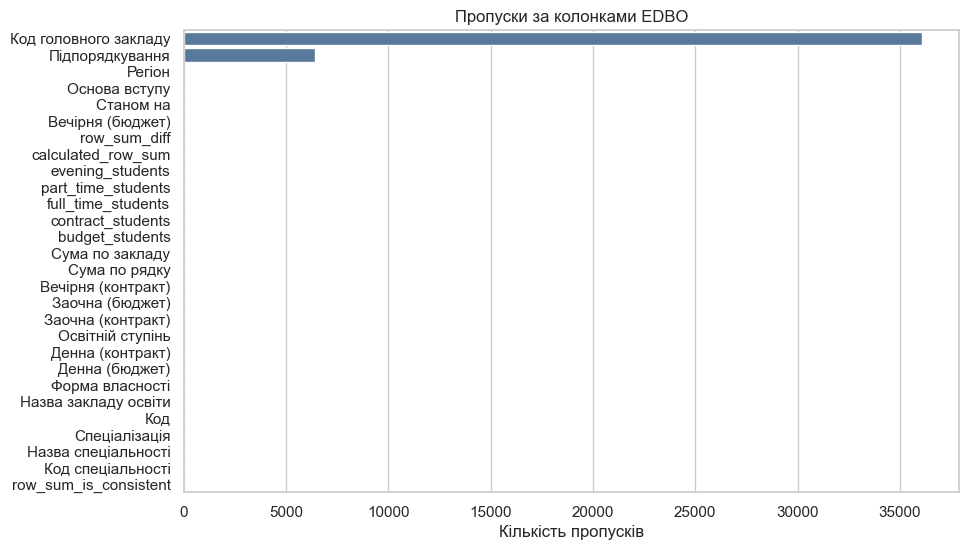

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=missing_values, x="missing_count", y="column", color="#4C78A8", ax=ax)
ax.set_title("Пропуски за колонками EDBO")
ax.set_xlabel("Кількість пропусків")
ax.set_ylabel("")
save_figure("02_missing_values_by_column.png", fig)
plt.show()


### Регіональний аналіз

In [13]:
region_summary = (
    df.groupby("Регіон", dropna=False)
    .agg(
        students=("Сума по рядку", "sum"),
        institutions=("Код", "nunique"),
        specialties=("Код спеціальності", "nunique"),
        budget_students=("budget_students", "sum"),
        contract_students=("contract_students", "sum"),
    )
    .reset_index()
)
region_summary["students_per_institution"] = region_summary["students"] / region_summary["institutions"]
region_summary["budget_share"] = region_summary["budget_students"] / region_summary["students"]
region_summary = region_summary.sort_values("students", ascending=False)

save_table(region_summary, "edbo_region_summary.csv")
region_summary.head(15)


,Регіон,students,institutions,specialties,budget_students,contract_students,students_per_institution,budget_share
8,Київ,276163,279,243,96305.0,179858,989.831541,0.348725
12,Львівська область,123709,85,213,52343.0,71366,1455.400000,0.423114
19,Харківська область,108718,100,225,48993.0,59725,1087.180000,0.450643
3,Дніпропетровська область,94969,101,213,49060.0,45909,940.287129,0.516590
14,Одеська область,85513,74,198,29826.0,55687,1155.581081,0.348789
7,Запорізька область,55700,46,179,22717.0,32983,1210.869565,0.407846
0,Івано-Франківська область,49942,46,169,20545.0,29397,1085.695652,0.411377
15,Полтавська область,49908,51,173,20533.0,29375,978.588235,0.411417
2,Вінницька область,48207,49,172,21086.0,27121,983.816327,0.437405
18,Тернопільська область,46536,31,162,20116.0,26420,1501.161290,0.432267


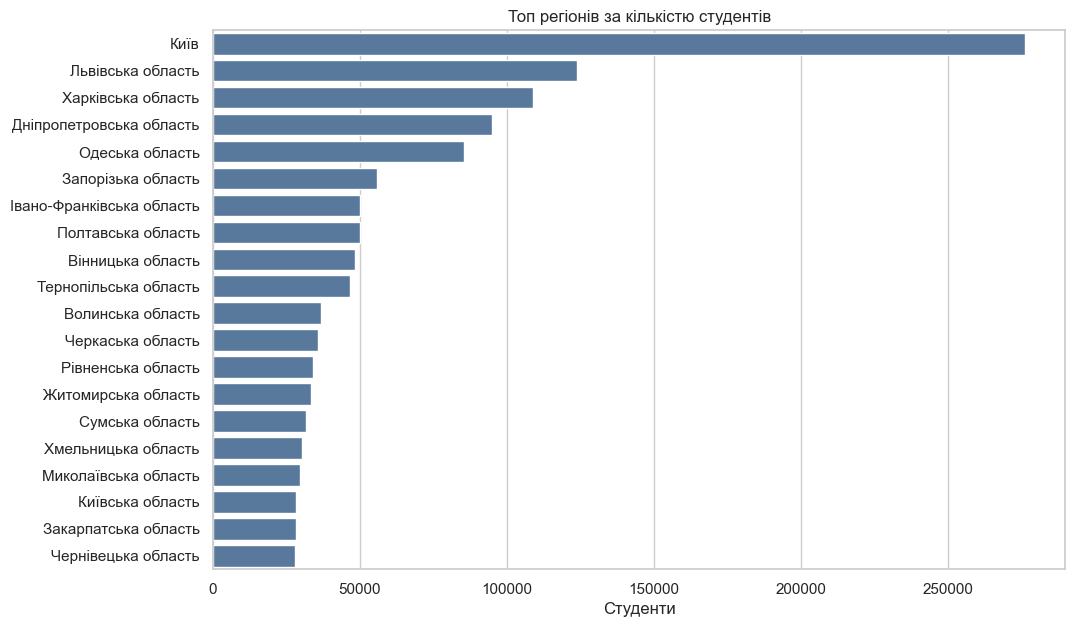

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=region_summary.head(20), x="students", y="Регіон", color="#4C78A8", ax=ax)
ax.set_title("Топ регіонів за кількістю студентів")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_students_by_region.png", fig)
plt.show()


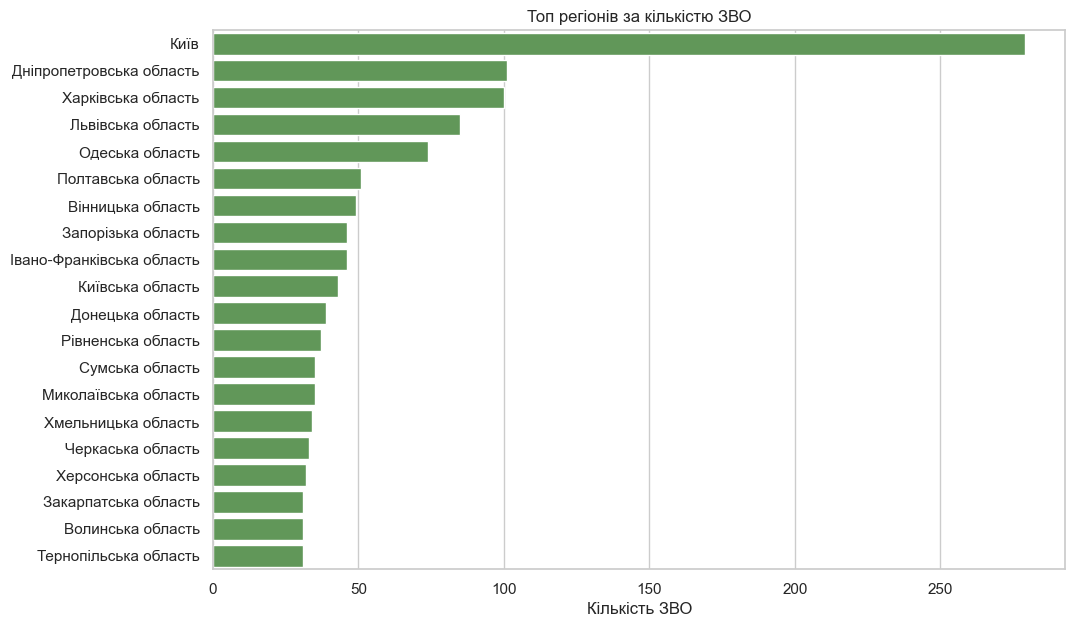

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=region_summary.sort_values("institutions", ascending=False).head(20), x="institutions", y="Регіон", color="#59A14F", ax=ax)
ax.set_title("Топ регіонів за кількістю ЗВО")
ax.set_xlabel("Кількість ЗВО")
ax.set_ylabel("")
save_figure("02_institutions_by_region.png", fig)
plt.show()


### Аналіз закладів

In [16]:
institution_summary = (
    df.groupby(["Код", "Назва закладу освіти", "Регіон", "Форма власності", "Підпорядкування"], dropna=False)
    .agg(
        students=("Сума по рядку", "sum"),
        reported_institution_students=("Сума по закладу", "max"),
        rows=("Сума по рядку", "size"),
        degrees=("Освітній ступінь", "nunique"),
        specialties=("Код спеціальності", "nunique"),
        budget_students=("budget_students", "sum"),
        contract_students=("contract_students", "sum"),
    )
    .reset_index()
)
institution_summary["budget_share"] = institution_summary["budget_students"] / institution_summary["students"]
institution_summary["reported_minus_grouped_students"] = institution_summary["reported_institution_students"] - institution_summary["students"]
institution_summary = institution_summary.sort_values("students", ascending=False)

save_table(institution_summary, "edbo_institution_summary.csv")
institution_summary.head(20)


,Код,Назва закладу освіти,Регіон,Форма власності,Підпорядкування,students,reported_institution_students,rows,degrees,specialties,budget_students,contract_students,budget_share,reported_minus_grouped_students
60,97,"Національний університет ""Львівська політехніка""",Львівська область,Державна,Міністерство освіти і науки України,30436,30436,475,3,135,14704.0,15732,0.483112,0
23,41,Київський національний університет імені Тарас...,Київ,Державна,Міністерство освіти і науки України,26192,26192,431,4,103,13940.0,12252,0.532224,0
171,282,Львівський національний університет імені Іван...,Львівська область,Державна,Міністерство освіти і науки України,21885,21885,374,3,106,9805.0,12080,0.448024,0
105,174,Національний технічний університет України «Ки...,Київ,Державна,Міністерство освіти і науки України,18594,18594,312,3,101,13758.0,4836,0.739916,0
3,7,Національний університет біоресурсів і природо...,Київ,Державна,Міністерство освіти і науки України,15875,15875,330,3,99,6671.0,9204,0.420220,0
1235,6594,Державний торговельно-економічний університет,Київ,Державна,Міністерство освіти і науки України,15416,15416,225,3,59,2425.0,12991,0.157304,0
201,341,Карпатський національний університет імені Вас...,Івано-Франківська область,Державна,Міністерство освіти і науки України,14214,14214,415,3,99,4218.0,9996,0.296750,0
37,62,Харківський національний університет імені В.Н...,Харківська область,Державна,Міністерство освіти і науки України,13412,13412,404,3,105,5309.0,8103,0.395840,0
36,61,Чернівецький національний університет імені Юр...,Чернівецька область,Державна,Міністерство освіти і науки України,13328,13328,455,3,119,5353.0,7975,0.401636,0
124,207,"Державний вищий навчальний заклад ""Ужгородськи...",Закарпатська область,Державна,Міністерство освіти і науки України,12460,12460,449,4,121,4306.0,8154,0.345586,0


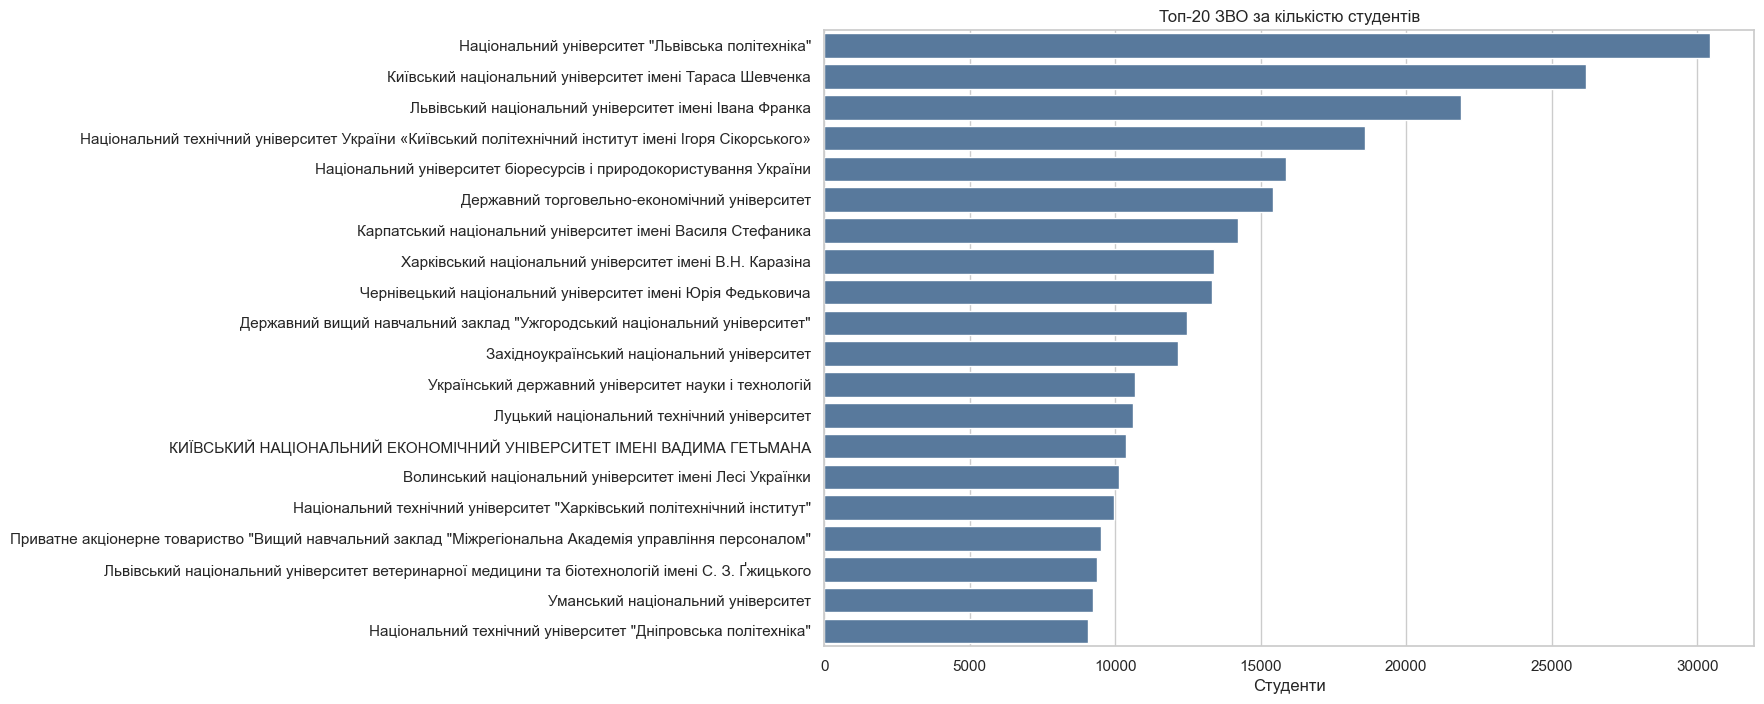

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=institution_summary.head(20), x="students", y="Назва закладу освіти", color="#4C78A8", ax=ax)
ax.set_title("Топ-20 ЗВО за кількістю студентів")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_top20_institutions_by_students.png", fig)
plt.show()


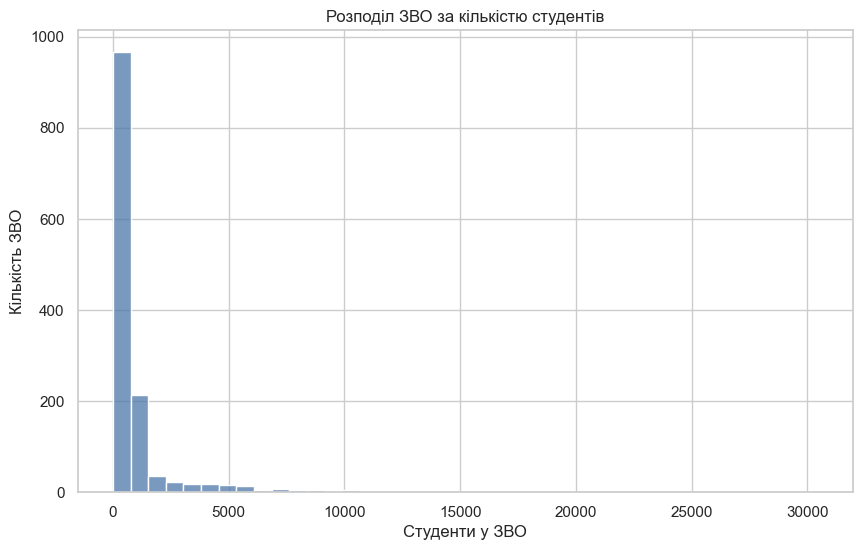

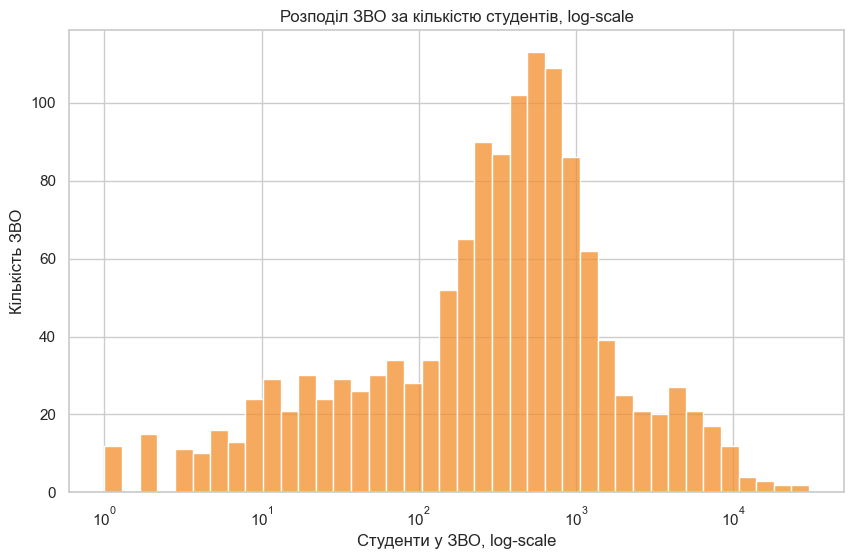

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=institution_summary, x="students", bins=40, color="#4C78A8", ax=ax)
ax.set_title("Розподіл ЗВО за кількістю студентів")
ax.set_xlabel("Студенти у ЗВО")
ax.set_ylabel("Кількість ЗВО")
save_figure("02_institution_size_distribution.png", fig)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=institution_summary.query("students > 0"), x="students", bins=40, log_scale=True, color="#F28E2B", ax=ax)
ax.set_title("Розподіл ЗВО за кількістю студентів, логарифмічна шкала")
ax.set_xlabel("Студенти у ЗВО, логарифмічна шкала")
ax.set_ylabel("Кількість ЗВО")
save_figure("02_institution_size_distribution_log.png", fig)
plt.show()


### Освітні ступені та спеціальності

In [19]:
degree_summary = (
    df.groupby("Освітній ступінь", dropna=False)
    .agg(
        students=("Сума по рядку", "sum"),
        rows=("Сума по рядку", "size"),
        institutions=("Код", "nunique"),
        specialties=("Код спеціальності", "nunique"),
        budget_students=("budget_students", "sum"),
        contract_students=("contract_students", "sum"),
    )
    .reset_index()
)
degree_summary["student_share"] = degree_summary["students"] / degree_summary["students"].sum()
degree_summary["budget_share"] = degree_summary["budget_students"] / degree_summary["students"]
degree_summary = degree_summary.sort_values("students", ascending=False)

save_table(degree_summary, "edbo_degree_summary.csv")
degree_summary


,Освітній ступінь,students,rows,institutions,specialties,budget_students,contract_students,student_share,budget_share
0,Бакалавр,710964,21488,398,242,252957.0,458007,0.535436,0.355794
6,Фаховий молодший бакалавр,404627,13778,817,154,219377.0,185250,0.304730,0.542171
2,Магістр,164800,6778,306,221,63151.0,101649,0.124113,0.383198
1,Доктор філософії,46816,3840,395,219,19469.0,27347,0.035258,0.415862
4,Молодший спеціаліст,473,210,130,65,159.0,314,0.000356,0.336152
5,Спеціаліст,117,33,22,19,4.0,113,0.000088,0.034188
3,Молодший бакалавр,25,3,2,1,0.0,25,0.000019,0.000000


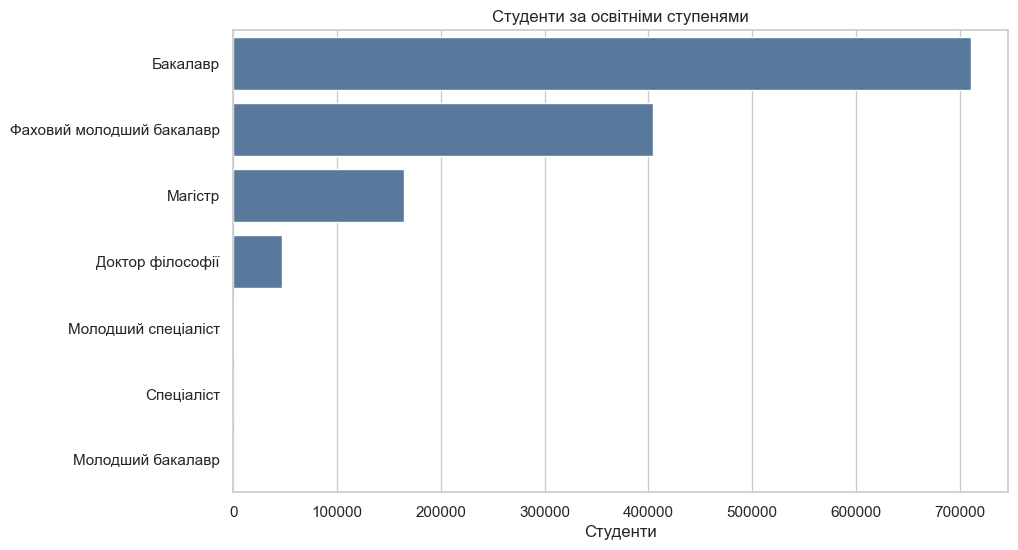

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=degree_summary, x="students", y="Освітній ступінь", color="#4C78A8", ax=ax)
ax.set_title("Студенти за освітніми ступенями")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_students_by_degree.png", fig)
plt.show()


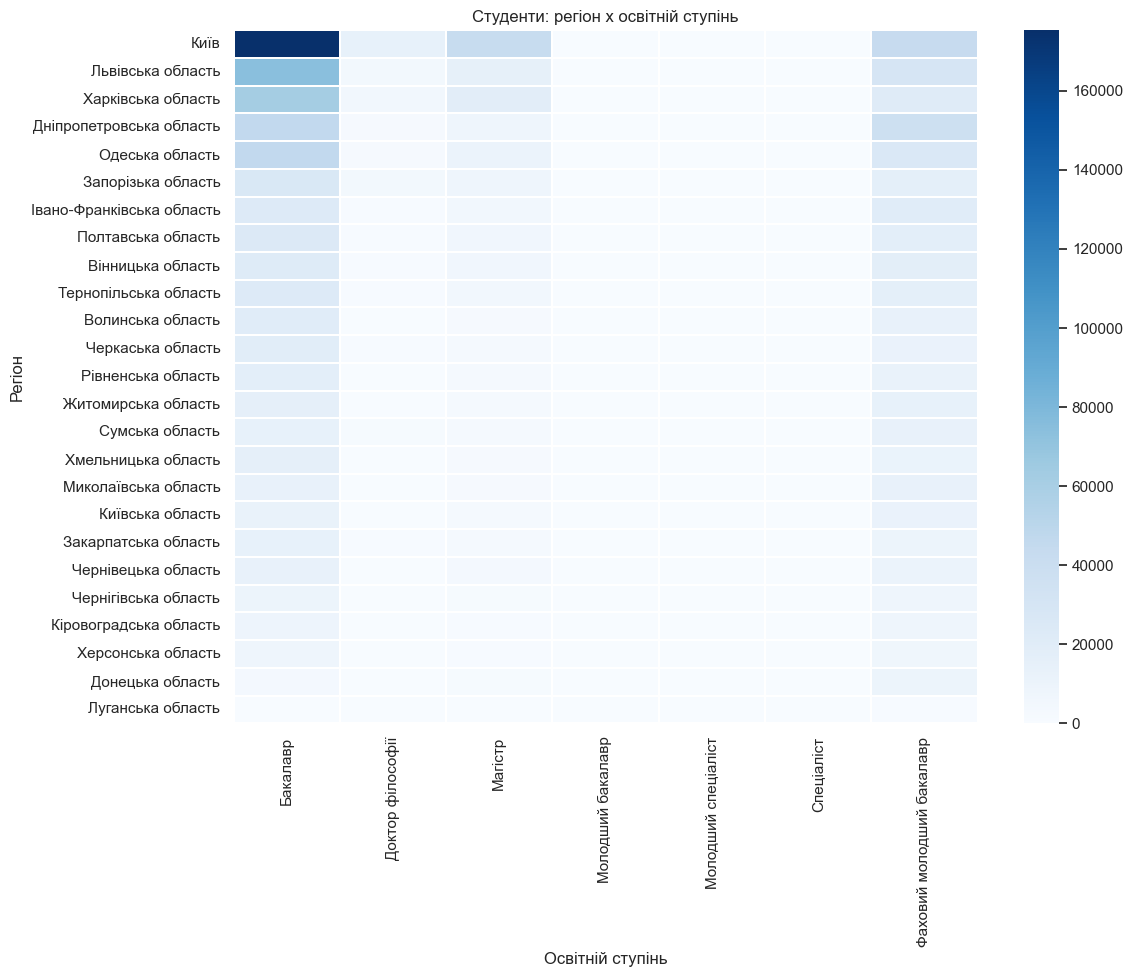

In [21]:
degree_region = df.pivot_table(
    index="Регіон",
    columns="Освітній ступінь",
    values="Сума по рядку",
    aggfunc="sum",
    fill_value=0,
)
degree_region = degree_region.loc[degree_region.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(degree_region, cmap="Blues", linewidths=0.2, ax=ax)
ax.set_title("Студенти: регіон x освітній ступінь")
ax.set_xlabel("Освітній ступінь")
ax.set_ylabel("Регіон")
save_figure("02_students_by_degree_region_heatmap.png", fig)
plt.show()


In [22]:
specialty_summary = (
    df.groupby(["Код спеціальності", "Назва спеціальності"], dropna=False)
    .agg(
        students=("Сума по рядку", "sum"),
        institutions=("Код", "nunique"),
        regions=("Регіон", "nunique"),
        degrees=("Освітній ступінь", "nunique"),
        budget_students=("budget_students", "sum"),
        contract_students=("contract_students", "sum"),
    )
    .reset_index()
)
specialty_summary["budget_share"] = specialty_summary["budget_students"] / specialty_summary["students"]
specialty_summary = specialty_summary.sort_values("students", ascending=False)

save_table(specialty_summary, "edbo_specialty_summary.csv")
specialty_summary.head(20)


,Код спеціальності,Назва спеціальності,students,institutions,regions,degrees,budget_students,contract_students,budget_share
36,081,Право,58016,288,24,6,5132.0,52884,0.088458
31,073,Менеджмент,39985,320,25,5,6291.0,33694,0.157334
25,053,Психологія,32806,174,24,4,4306.0,28500,0.131256
4,014,Середня освіта,31392,119,24,6,20131.0,11261,0.641278
241,D3,Менеджмент,29432,428,25,4,4003.0,25429,0.136008
235,C4,Психологія,27336,179,24,3,2209.0,25127,0.080809
105,223,Медсестринство,26489,112,25,5,18014.0,8475,0.680056
49,122,Комп'ютерні науки,26260,184,24,5,13839.0,12421,0.526999
89,192,Будівництво та цивільна інженерія,25186,135,24,5,14802.0,10384,0.587707
48,121,Інженерія програмного забезпечення,25094,173,24,5,13542.0,11552,0.539651


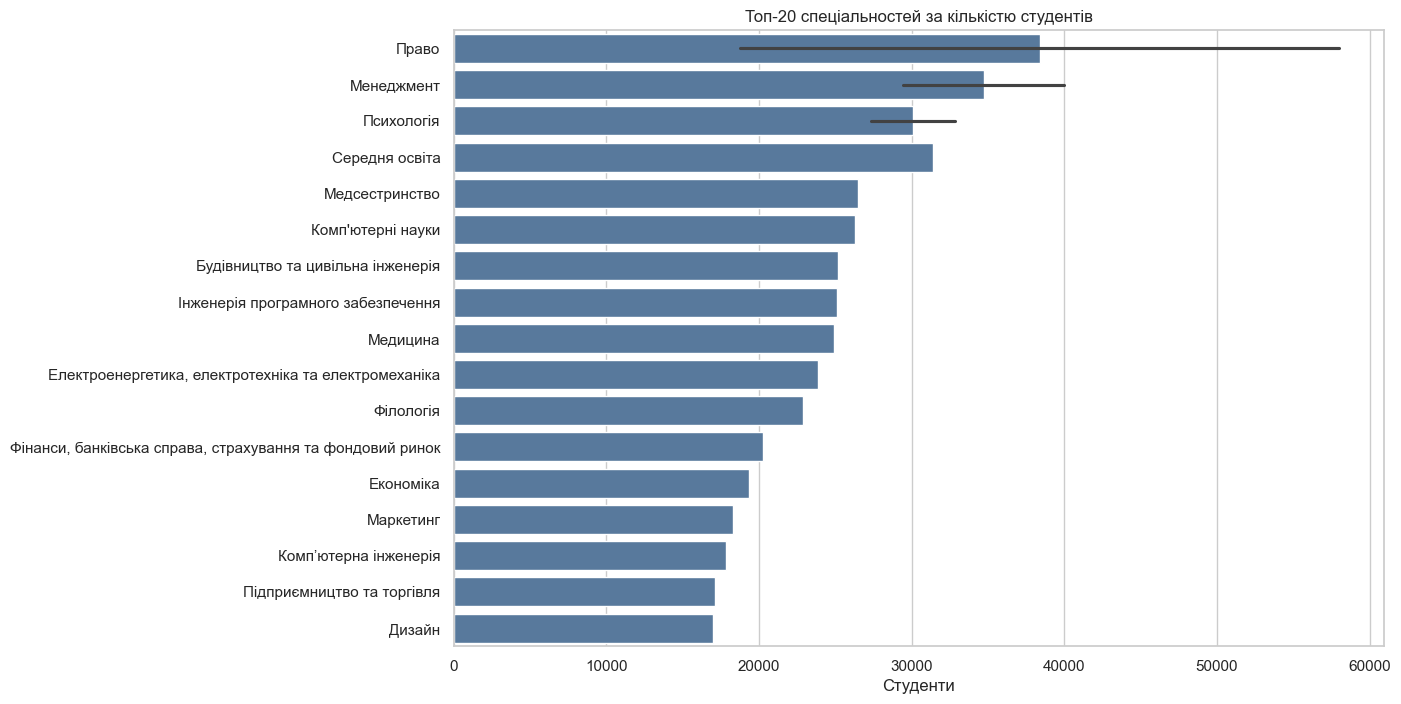

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=specialty_summary.head(20), x="students", y="Назва спеціальності", color="#4C78A8", ax=ax)
ax.set_title("Топ-20 спеціальностей за кількістю студентів")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_top20_specialties_by_students.png", fig)
plt.show()


### Бюджет, контракт і форми навчання

In [24]:
budget_contract_summary = pd.DataFrame({
    "funding_type": ["Бюджет", "Контракт"],
    "students": [df["budget_students"].sum(), df["contract_students"].sum()],
})
budget_contract_summary["share"] = budget_contract_summary["students"] / budget_contract_summary["students"].sum()

save_table(budget_contract_summary, "edbo_budget_contract_summary.csv")
budget_contract_summary


,funding_type,students,share
0,Бюджет,555117.0,0.418066
1,Контракт,772705.0,0.581934


/var/folders/s4/_r_9fdf57l38c4jf09hmrjt00000gn/T/ipykernel_50692/2424662135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=budget_contract_summary, x="funding_type", y="students", palette=["#4C78A8", "#F28E2B"], ax=ax)


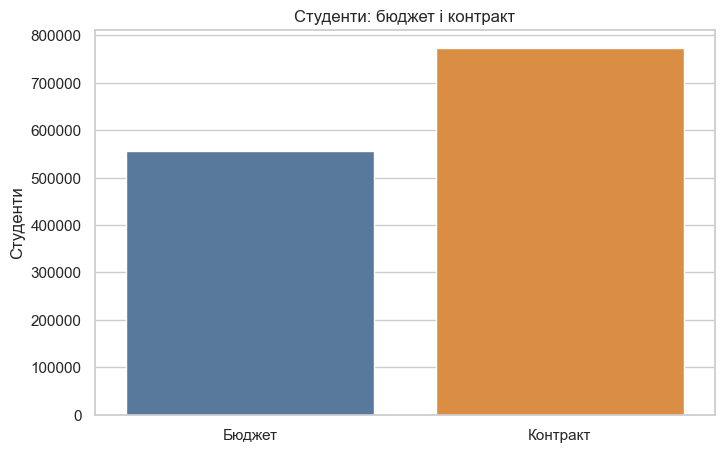

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=budget_contract_summary, x="funding_type", y="students", palette=["#4C78A8", "#F28E2B"], ax=ax)
ax.set_title("Студенти: бюджет і контракт")
ax.set_xlabel("")
ax.set_ylabel("Студенти")
save_figure("02_budget_contract_share.png", fig)
plt.show()


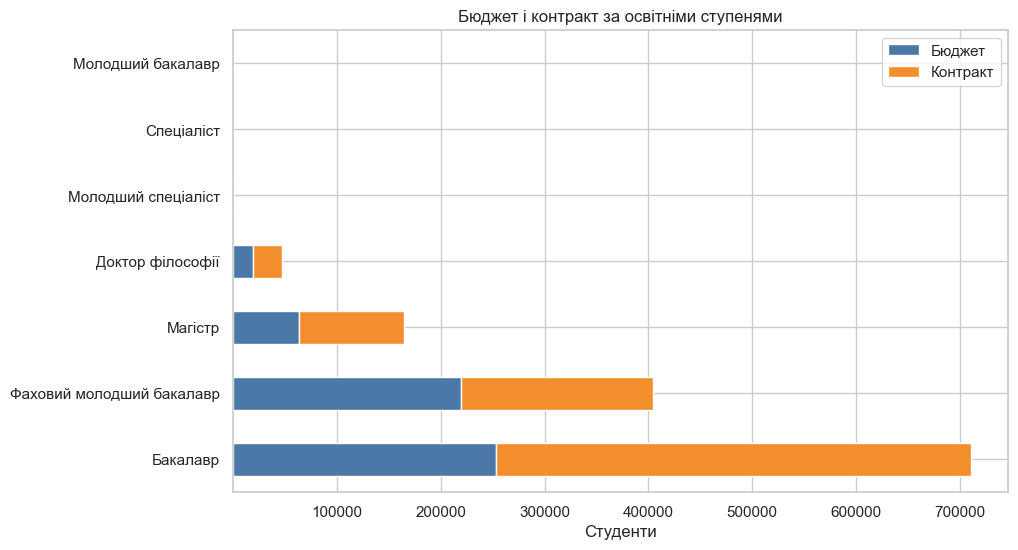

In [26]:
degree_funding = degree_summary[["Освітній ступінь", "budget_students", "contract_students"]].copy()
degree_funding = degree_funding.set_index("Освітній ступінь")

fig, ax = plt.subplots(figsize=(10, 6))
degree_funding.plot(kind="barh", stacked=True, color=["#4C78A8", "#F28E2B"], ax=ax)
ax.set_title("Бюджет і контракт за освітніми ступенями")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
ax.legend(["Бюджет", "Контракт"], title="")
save_figure("02_budget_contract_by_degree.png", fig)
plt.show()


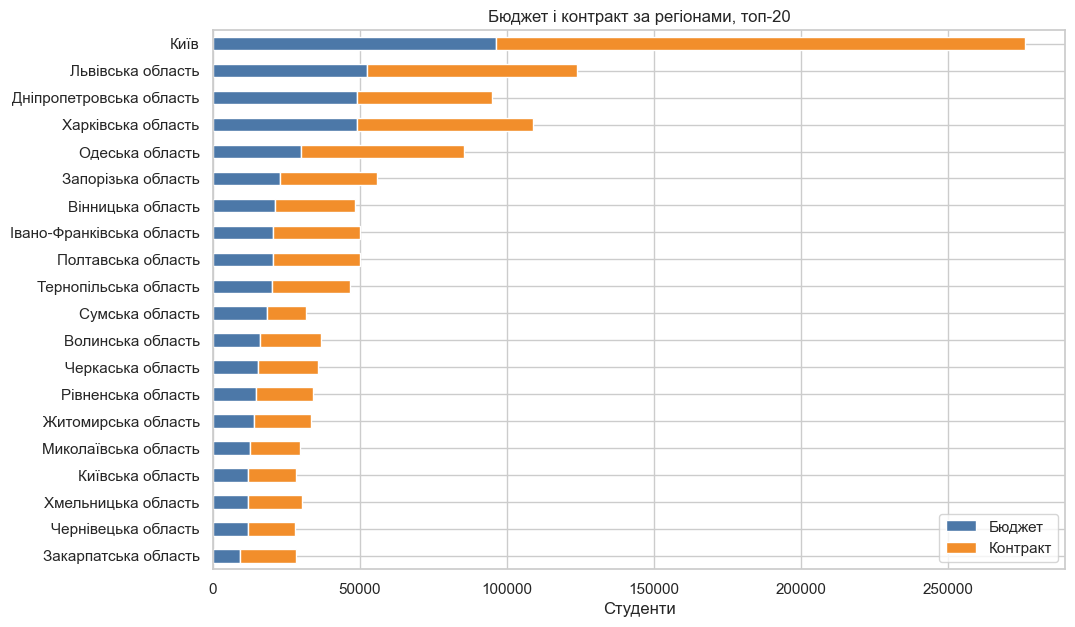

In [27]:
region_funding = region_summary.head(20).set_index("Регіон")[["budget_students", "contract_students"]]

fig, ax = plt.subplots(figsize=(11, 7))
region_funding.sort_values(["budget_students", "contract_students"], ascending=True).plot(
    kind="barh",
    stacked=True,
    color=["#4C78A8", "#F28E2B"],
    ax=ax,
)
ax.set_title("Бюджет і контракт за регіонами, топ-20")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
ax.legend(["Бюджет", "Контракт"], title="")
save_figure("02_budget_contract_by_region.png", fig)
plt.show()


In [28]:
study_form_summary = pd.DataFrame({
    "study_form": ["Денна", "Заочна", "Вечірня"],
    "students": [
        df["full_time_students"].sum(),
        df["part_time_students"].sum(),
        df["evening_students"].sum(),
    ],
})
study_form_summary["share"] = study_form_summary["students"] / study_form_summary["students"].sum()

save_table(study_form_summary, "edbo_study_form_summary.csv")
study_form_summary


,study_form,students,share
0,Денна,1087831.0,0.819260
1,Заочна,236625.0,0.178205
2,Вечірня,3366.0,0.002535


/var/folders/s4/_r_9fdf57l38c4jf09hmrjt00000gn/T/ipykernel_50692/3014932678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=study_form_summary, x="study_form", y="students", palette=["#4C78A8", "#59A14F", "#E15759"], ax=ax)


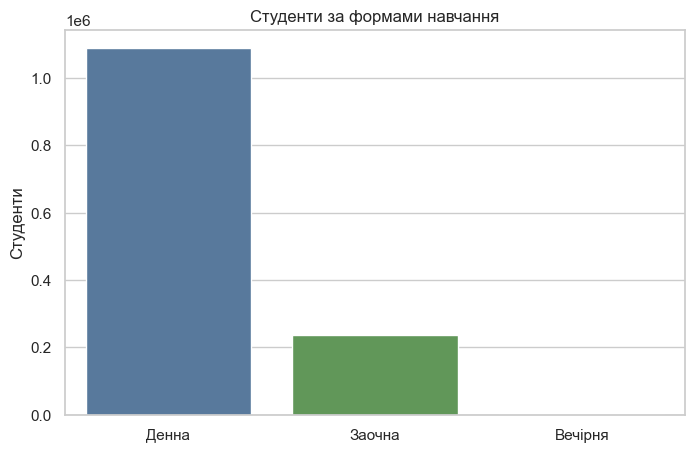

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=study_form_summary, x="study_form", y="students", palette=["#4C78A8", "#59A14F", "#E15759"], ax=ax)
ax.set_title("Студенти за формами навчання")
ax.set_xlabel("")
ax.set_ylabel("Студенти")
save_figure("02_study_form_share.png", fig)
plt.show()


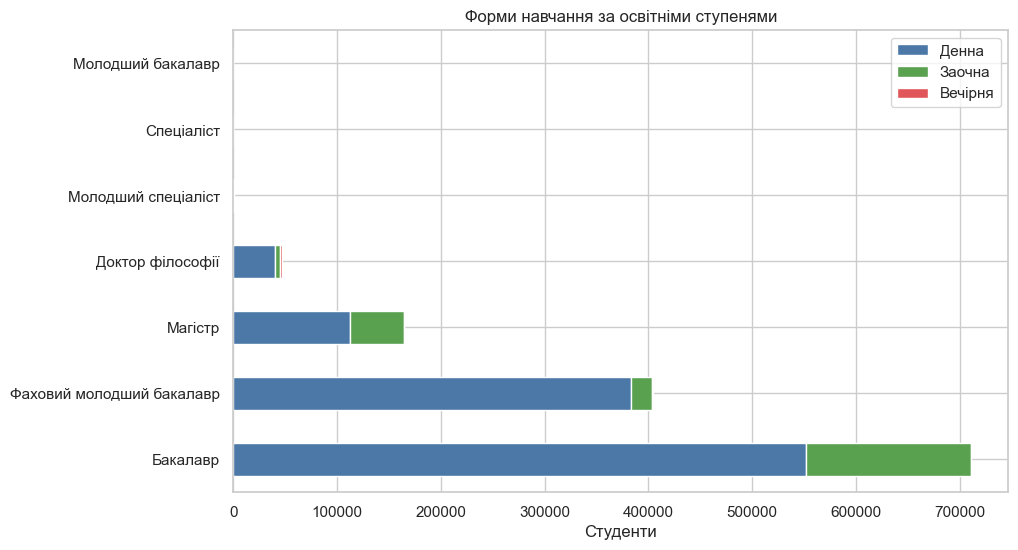

In [30]:
degree_study_form = (
    df.groupby("Освітній ступінь", dropna=False)[["full_time_students", "part_time_students", "evening_students"]]
    .sum()
    .loc[degree_summary["Освітній ступінь"]]
)

fig, ax = plt.subplots(figsize=(10, 6))
degree_study_form.plot(kind="barh", stacked=True, color=["#4C78A8", "#59A14F", "#E15759"], ax=ax)
ax.set_title("Форми навчання за освітніми ступенями")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
ax.legend(["Денна", "Заочна", "Вечірня"], title="")
save_figure("02_study_form_by_degree.png", fig)
plt.show()


### Форма власності та підпорядкування

In [31]:
ownership_summary = (
    df.groupby("Форма власності", dropna=False)
    .agg(students=("Сума по рядку", "sum"), institutions=("Код", "nunique"))
    .reset_index()
    .sort_values("students", ascending=False)
)

governing_summary = (
    df.groupby("Підпорядкування", dropna=False)
    .agg(students=("Сума по рядку", "sum"), institutions=("Код", "nunique"))
    .reset_index()
    .sort_values("students", ascending=False)
)

save_table(ownership_summary, "edbo_ownership_summary.csv")
save_table(governing_summary, "edbo_governing_body_summary.csv")
ownership_summary


,Форма власності,students,institutions
0,Державна,1081340,864
3,Приватна,147895,270
1,Комунальна,97732,210
2,Корпоративна,855,1


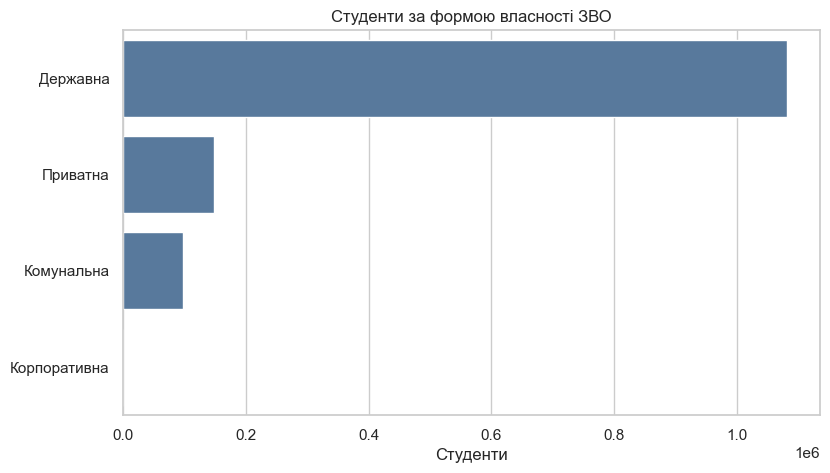

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=ownership_summary, x="students", y="Форма власності", color="#4C78A8", ax=ax)
ax.set_title("Студенти за формою власності ЗВО")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_students_by_ownership_type.png", fig)
plt.show()


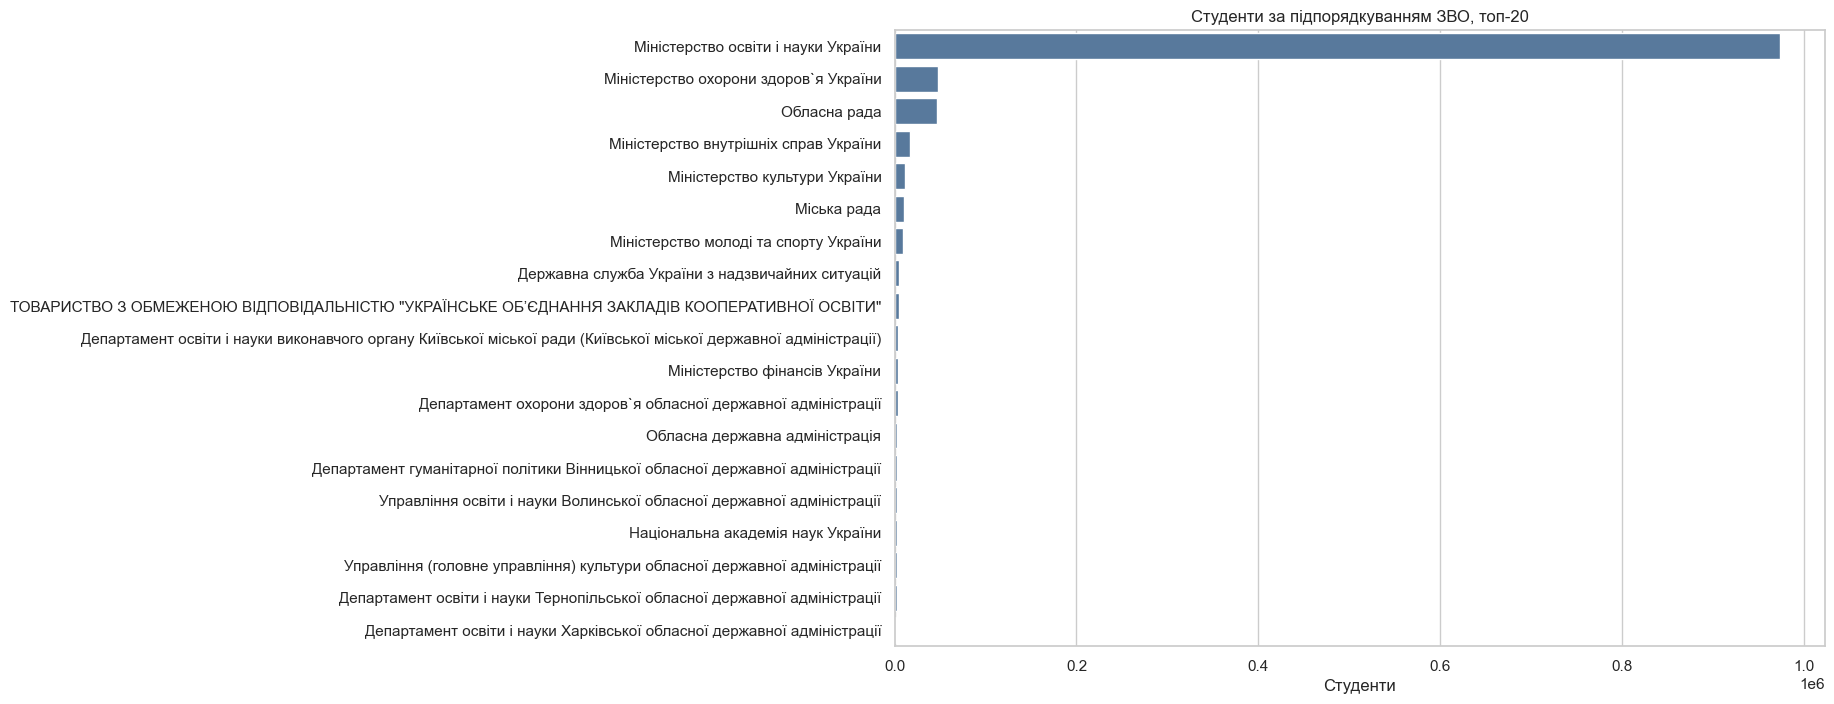

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=governing_summary.head(20), x="students", y="Підпорядкування", color="#4C78A8", ax=ax)
ax.set_title("Студенти за підпорядкуванням ЗВО, топ-20")
ax.set_xlabel("Студенти")
ax.set_ylabel("")
save_figure("02_students_by_governing_body.png", fig)
plt.show()


### Перевірки узгодженості

In [34]:
consistency_checks = pd.DataFrame([
    {"check": "row_sum_consistent", "rows": int(df["row_sum_is_consistent"].sum())},
    {"check": "row_sum_inconsistent", "rows": int((~df["row_sum_is_consistent"]).sum())},
    {"check": "zero_row_sum", "rows": int(df["Сума по рядку"].eq(0).sum())},
    {"check": "negative_row_sum", "rows": int(df["Сума по рядку"].lt(0).sum())},
    {"check": "missing_region", "rows": int(df["Регіон"].isna().sum())},
    {"check": "missing_institution_name", "rows": int(df["Назва закладу освіти"].isna().sum())},
])

inconsistent_rows = df.loc[~df["row_sum_is_consistent"]].copy()
save_table(consistency_checks, "edbo_consistency_checks.csv")
save_table(inconsistent_rows, "edbo_inconsistent_row_sums.csv")
consistency_checks


,check,rows
0,row_sum_consistent,46130
1,row_sum_inconsistent,0
2,zero_row_sum,52
3,negative_row_sum,0
4,missing_region,24
5,missing_institution_name,0


/var/folders/s4/_r_9fdf57l38c4jf09hmrjt00000gn/T/ipykernel_50692/1560986310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=consistency_checks.head(2), x="check", y="rows", palette=["#59A14F", "#E15759"], ax=ax)


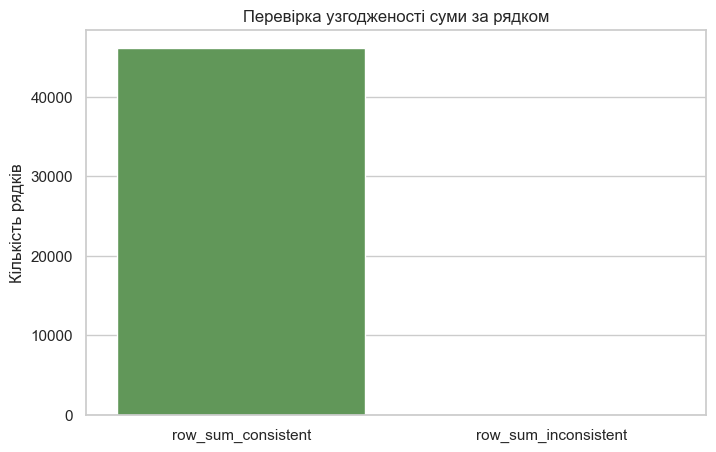

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=consistency_checks.head(2), x="check", y="rows", palette=["#59A14F", "#E15759"], ax=ax)
ax.set_title("Перевірка узгодженості суми за рядком")
ax.set_xlabel("")
ax.set_ylabel("Кількість рядків")
save_figure("02_row_sum_consistency_check.png", fig)
plt.show()


## Результати

Після виконання ноутбука в `data/processed/` зберігаються оглядові таблиці щодо якості даних, регіонів, закладів, освітніх ступенів, спеціальностей, бюджету/контракту, форм навчання, власності та перевірок узгодженості.

Графіки зберігаються в `figures/` з префіксом `02_` і показують розподіли студентів, структуру даних та ключові зрізи EDBO-вивантаження.


In [36]:
summary_results = {
    "total_students": int(df["Сума по рядку"].sum()),
    "unique_institutions": int(df["Код"].nunique()),
    "unique_regions": int(df["Регіон"].nunique()),
    "unique_specialties": int(df["Код спеціальності"].nunique()),
    "top_region": region_summary.iloc[0]["Регіон"],
    "top_institution": institution_summary.iloc[0]["Назва закладу освіти"],
    "top_degree": degree_summary.iloc[0]["Освітній ступінь"],
    "top_specialty": specialty_summary.iloc[0]["Назва спеціальності"],
    "budget_share": float(budget_contract_summary.loc[budget_contract_summary["funding_type"].eq("Бюджет"), "share"].iloc[0]),
    "contract_share": float(budget_contract_summary.loc[budget_contract_summary["funding_type"].eq("Контракт"), "share"].iloc[0]),
    "inconsistent_row_sum_rows": int((~df["row_sum_is_consistent"]).sum()),
}

summary_results


{'total_students': 1327822,
 'unique_institutions': 1345,
 'unique_regions': 25,
 'unique_specialties': 304,
 'top_region': 'Київ',
 'top_institution': 'Національний університет "Львівська політехніка"',
 'top_degree': 'Бакалавр',
 'top_specialty': 'Право',
 'budget_share': 0.4180658250880013,
 'contract_share': 0.5819341749119987,
 'inconsistent_row_sum_rows': 0}

## Перегляд результатів

- `Сума по рядку` використовується як основний показник чисельності студентів, бо вона відповідає деталізації рядка за ступенем, спеціальністю, закладом і формами навчання.
- `Сума по закладу` розглядається як контрольне поле: воно може повторюватися в кількох рядках одного закладу й не має напряму підсумовуватися по всьому датасету.
- Перед порівнянням з ETER потрібні нормалізація назв ЗВО, перевірка кодів закладів і узгодження року / дати вивантаження.
- Висновки за регіонами та спеціальностями відображають структуру поточного EDBO-вивантаження й залежать від повноти вихідного файлу.
